# Both tails: the default `ec_m` prior cannot represent under-reach *or* over-saturation

**The gap this closes.** Every notebook in this series so far tells a
one-sided story: TV is under-reached, its true `ec_m` of 11.07 exceeds the
default prior's hard upper bound, and an informed prior fixes it. A fair
listener will ask whether the argument is really "Meridian's default happens
to be wrong for one contrived channel."

Meridian's default `ec_m` prior is

```
TruncatedNormal(loc=0.8, scale=0.8, low=0.1, high=10.0)
```

-- bounded at **both** ends. So the symmetric failure should exist: a channel
saturated *past* the prior's lower bound of 0.1 should be just as
unrepresentable as one stretched past 10.

**This notebook builds both tails in a single scenario:**

| channel | true `ec_m` | ceiling at median | vs. prior support `[0.1, 10]` |
|---|---|---|---|
| TV | 11.07 | 8% | **above the ceiling** |
| Display | 1.35 | 42% | inside (the control) |
| Social | 0.074 | 93% | **below the floor** |

The predicted failures are mirror images. For TV, the posterior cannot reach
high enough, so the model believes a barely-tapped channel is nearly
saturated and **starves** it. For Social, the posterior cannot reach low
enough, so the model believes a tapped-out channel still has headroom and
**over-feeds** it. One prior, two opposite budget errors.

**How the scenario is built.** Starting from the Display-fixed, `alpha=0.8`
configuration, two changes:

1. `saturation_frequency['Social']`: 4.0 -> **1.0**. Since `ec_m` is
   proportional to `saturation_frequency / (reach * frequency)`, this scales
   Social's `ec_m` down 4x *without touching its impressions or spend* --
   unlike raising frequency, which would inflate Social's budget share to
   90%+ and crush the other two channels back into invisibility.
2. `target_audience_pop_frac['Display']`: 0.50 -> **0.70**. Saturating Social
   raises its ROI through the `roi_ec_elasticity=-0.3` coupling, which pulls
   contribution share away from Display (16% -> 12%) and would drop it back
   under its identifiability threshold. Audience is `ec_m`-neutral, so this
   restores Display's share without moving it on its curve.

**A caveat that matters for reading Section 1b.** The `detectability` metric
used throughout this series ignores that the `mu_t` spline and geo effects
compete to absorb the same variation. A deeply saturated channel's
contribution is closer to constant over time, which is exactly what the
baseline can soak up -- so the metric is *least* trustworthy precisely here.
Treat Social's detectability number as an upper bound and let the fit decide.

In [1]:
import json
import os
import time

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_probability as tfp

from meridian.model import model

from data_simulator import SimulationConfig
from model_utils import build_comparison_table
from model_utils import build_model_spec
from model_utils import build_real_augmented_input
from model_utils import ceiling_fraction_at_median

OUT_DIR = 'fitted_models/both_tails'
os.makedirs(OUT_DIR, exist_ok=True)
VARIANTS = ['default', 'ec_alpha_only']
MCMC_KWARGS = dict(n_chains=2, n_adapt=500, n_burnin=500, n_keep=1000, seed=1)
SIM_SEED = 0
EC_PRIOR_LOW, EC_PRIOR_HIGH = 0.1, 10.0  # meridian default ec_m support

## 1. Build the two-tailed scenario

In [2]:
BOTH_TAILS_CONFIG_OVERRIDES = {
    # Display 0.50 -> 0.70: ec_m-neutral, restores the share that saturating
    # Social pulls away (see header).
    'target_audience_pop_frac': {'TV': 0.60, 'Display': 0.70, 'Social': 0.15},
    'current_reach_frac': {'TV': 0.10, 'Display': 0.5, 'Social': 0.9},
    'frequency_range': {'TV': (1, 2), 'Display': (1, 5), 'Social': (7.0, 8.0)},
    'target_roi': {'TV': 8.0, 'Display': 5.0, 'Social': 3.0},
    'max_lag': 13,
    'n_times': 156,
    'n_knots_mu_t': 8,
    'roi_ec_elasticity': -0.3,
    'roi_alpha_elasticity': 0.3,
    'adstock_retention_range': {
        'TV': (0.8, 0.8), 'Display': (0.0, 0.3), 'Social': (0.1, 0.4),
    },
    # The new part: Social saturates at 1 exposure/week rather than 4, so its
    # ec_m falls 4x. Scales ec_m only -- impressions and spend are untouched.
    'saturation_frequency': {'TV': 4.0, 'Display': 4.0, 'Social': 1.0},
}

real_df = pd.read_csv(
    'https://raw.githubusercontent.com/google/meridian/refs/heads/main/meridian/data/simulated_data/csv/geo_media_rf.csv'
)
np.random.seed(SIM_SEED)
tf.random.set_seed(SIM_SEED)
config = SimulationConfig.from_dict(BOTH_TAILS_CONFIG_OVERRIDES)
sim, data, ground_truth = build_real_augmented_input(
    config, real_df,
    rf_source_map={'TV': 'Channel3'},
    plain_source_map={'Display': 'Channel2', 'Social': 'Channel1'},
)
channels = list(config.channel_names)
true_ec_m = sim.ec_m.numpy()
ceiling_frac = ceiling_fraction_at_median(true_ec_m)
i_tv, i_disp, i_soc = (channels.index(c) for c in ['TV', 'Display', 'Social'])

# The entire premise: one channel past each end of the prior's support.
assert true_ec_m[i_tv] > EC_PRIOR_HIGH, (
    f'TV ec_m {true_ec_m[i_tv]:.3f} is inside the prior support -- the upper'
    ' tail of this scenario has collapsed.')
assert true_ec_m[i_soc] < EC_PRIOR_LOW, (
    f'Social ec_m {true_ec_m[i_soc]:.4f} is inside the prior support -- the'
    ' lower tail has collapsed; lower saturation_frequency further.')
assert EC_PRIOR_LOW < true_ec_m[i_disp] < EC_PRIOR_HIGH, 'Display should be the control'

print('true ec_m   :', np.round(true_ec_m, 4))
print('ceiling frac:', np.round(ceiling_frac, 3))
print('true alpha_m:', np.round(sim.alpha_m.numpy(), 3))
print('true roi_m  :', np.round(np.asarray(ground_truth['roi_m']), 3))

ec_m = [11.069365    1.350547    0.07422373]
true ec_m   : [11.0694  1.3505  0.0742]
ceiling frac: [0.083 0.425 0.931]
true alpha_m: [0.8   0.078 0.252]
true roi_m  : [5.563 3.256 6.625]


I0000 00:00:1785262546.660342 9205246 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


### 1a. Where each channel sits, and the prior that has to cover them

The plot uses a log x-axis because the three true values span more than two
orders of magnitude -- itself the point. A single `TruncatedNormal(0.8, 0.8)`
on `[0.1, 10]`, applied identically to every channel, has to serve all three.

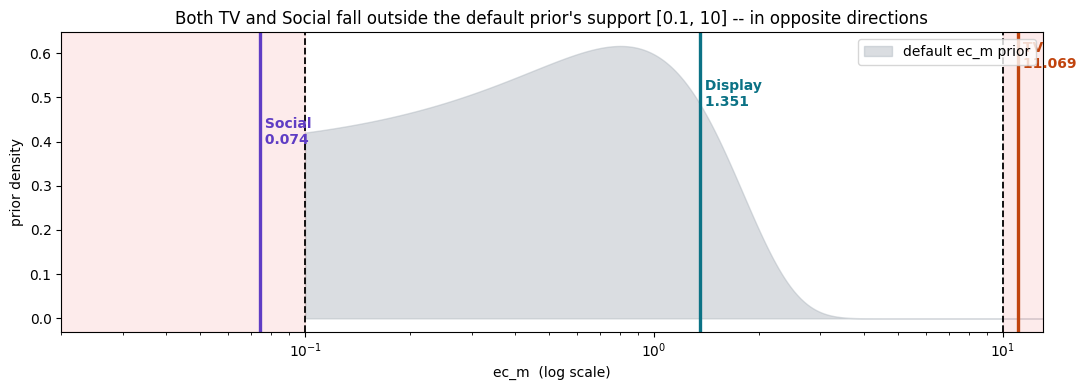

,channel,true_ec_m,ceiling_frac_at_median,position,prior_density_at_truth
0,TV,11.0694,0.083,ABOVE prior ceiling,0.00000
1,Display,1.3505,0.425,inside support,0.48631
2,Social,0.0742,0.931,BELOW prior floor,0.00000


In [3]:
ec_prior = tfp.distributions.TruncatedNormal(
    0.8, 0.8, EC_PRIOR_LOW, EC_PRIOR_HIGH)
grid = np.linspace(EC_PRIOR_LOW, 13.0, 1200, dtype=np.float32)
dens = ec_prior.prob(grid).numpy()
colors = {'TV': '#c1440e', 'Display': '#0b7285', 'Social': '#5f3dc4'}

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(grid, dens, color='#adb5bd', alpha=0.45,
                label='default ec_m prior')
for bound in (EC_PRIOR_LOW, EC_PRIOR_HIGH):
    ax.axvline(bound, color='k', ls='--', lw=1.3)
ax.axvspan(0.02, EC_PRIOR_LOW, color='#f03e3e', alpha=0.10)
ax.axvspan(EC_PRIOR_HIGH, 13.0, color='#f03e3e', alpha=0.10)
for i, ch in enumerate(channels):
    t = float(true_ec_m[i])
    ax.axvline(t, color=colors[ch], lw=2.4)
    ax.text(t, dens.max() * (0.92 - 0.14 * i), f' {ch}\n {t:.3f}',
            color=colors[ch], fontsize=10, fontweight='bold')
ax.set_xscale('log')
ax.set_xlim(0.02, 13.0)
ax.set_xlabel('ec_m  (log scale)')
ax.set_ylabel('prior density')
ax.set_title('Both TV and Social fall outside the default prior\'s support '
             '[0.1, 10] -- in opposite directions')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

pd.DataFrame([{
    'channel': ch,
    'true_ec_m': round(float(true_ec_m[i]), 4),
    'ceiling_frac_at_median': round(float(ceiling_frac[i]), 3),
    'position': ('BELOW prior floor' if true_ec_m[i] < EC_PRIOR_LOW
                 else 'ABOVE prior ceiling' if true_ec_m[i] > EC_PRIOR_HIGH
                 else 'inside support'),
    'prior_density_at_truth': round(
        float(ec_prior.prob(np.float32(true_ec_m[i])).numpy()), 5),
} for i, ch in enumerate(channels)])

### 1b. Delivery, contribution and identifiability

Social should still be *identifiable* (it is large and its delivery varies),
just unrepresentable by the default prior. Display must stay above the
detectability threshold that the audience bump was meant to protect --
otherwise this scenario would silently re-break the fix from
`tv-test-under-real-demo-data-display-fix.ipynb`.

In [4]:
def shape_diagnostics(sim, config, ec_multiple=2.0):
  """Per-channel delivery range, contribution share and ec_m detectability."""
  ec = sim.ec_m.numpy()
  x = sim.transformed_ipc_gtm.numpy()
  contrib = sim.media_transformed.numpy() * sim.beta_gm.numpy()[:, None, :]
  se = float(sim.sigma.numpy()[0]) / np.sqrt(contrib.shape[0] * contrib.shape[1])
  hill = lambda v, e: v / (v + e)
  rows = []
  for i, ch in enumerate(config.channel_names):
    v = x[:, :, i].ravel()
    v = v[v > 0]
    p5, p95 = np.percentile(v, [5, 95])
    true_curve, wrong_curve = hill(v, ec[i]), hill(v, ec[i] * ec_multiple)
    best = (true_curve @ wrong_curve) / (wrong_curve @ wrong_curve)
    frac = (np.sqrt(((true_curve - best * wrong_curve) ** 2).mean())
            / np.sqrt((true_curve ** 2).mean()))
    mean_contrib = contrib[:, :, i].mean()
    rows.append({
        'channel': ch,
        'ceiling_frac': round(float(1 / (1 + ec[i])), 3),
        'hill_p5': round(float(hill(p5, ec[i])), 3),
        'hill_p95': round(float(hill(p95, ec[i])), 3),
        'contrib_share_pct': round(
            float(mean_contrib / contrib.mean(axis=(0, 1)).sum() * 100), 1),
        'detectability': round(float(frac * mean_contrib / se), 2),
    })
  return pd.DataFrame(rows)


diag = shape_diagnostics(sim, config)
assert diag.loc[diag.channel == 'Display', 'detectability'].iloc[0] > 1.3, (
    'Display fell back below its identifiability threshold -- raise its'
    ' target_audience_pop_frac further.')
diag

,channel,ceiling_frac,hill_p5,hill_p95,contrib_share_pct,detectability
0,TV,0.083,0.017,0.163,11.7,0.39
1,Display,0.425,0.150,0.598,15.6,1.58
2,Social,0.931,0.794,0.961,72.7,4.50


## 2. Fit `default` vs. `ec_alpha_only`

Fitted in-notebook rather than loaded from disk: `save_mmm` uses plain
`joblib`, so a pickle is only readable by the Meridian build that wrote it,
and this repo has both a system install and the editable repo install
reachable depending on interpreter. Fitting here keeps the models native to
whatever kernel runs the notebook.

In [5]:
np.savez(os.path.join(OUT_DIR, 'ground_truth.npz'),
         **{a: np.asarray(getattr(sim, a).numpy()) for a in
            ['ec_m', 'alpha_m', 'slope_m', 'beta_m', 'beta_gm', 'eta_m',
             'target_roi_m']},
         **{f'gt_{k}': np.asarray(v) for k, v in ground_truth.items()},
         ceiling_fraction=ceiling_frac)
with open(os.path.join(OUT_DIR, 'ground_truth.json'), 'w') as f:
    json.dump({'channel_names': channels,
               'ec_m': true_ec_m.tolist(),
               'ceiling_fraction': ceiling_frac.tolist(),
               'roi_m': np.asarray(ground_truth['roi_m']).tolist(),
               'sim_seed': SIM_SEED,
               'config_overrides': {k: str(v) for k, v in
                                    BOTH_TAILS_CONFIG_OVERRIDES.items()}},
              f, indent=2)
diag.to_csv(os.path.join(OUT_DIR, 'shape_diagnostics.csv'), index=False)

fitted_mmms = {}
for variant in VARIANTS:
  t0 = time.time()
  model_spec = build_model_spec(
      variant, sim, config, media_prior_type='coefficient')
  mmm = model.Meridian(input_data=data, model_spec=model_spec)
  mmm.sample_prior(500)
  mmm.sample_posterior(**MCMC_KWARGS)
  fitted_mmms[variant] = mmm
  mmm.inference_data.to_netcdf(
      os.path.join(OUT_DIR, f'{variant}_inference_data.nc'))
  print(f'{variant}: {time.time() - t0:.0f}s')

comparison = build_comparison_table(
    fitted_mmms, config, sim, ground_truth, hdi_prob=0.9)
comparison.to_csv(os.path.join(OUT_DIR, 'comparison_table.csv'), index=False)
comparison

/Users/mariappan.subramanian/Documents/repo/meridian/build/__editable__.google_meridian-1.7.0-py3-none-any/meridian/model/spec.py:329: UserWarning: Using coefficient priors (`coefficient`) is not recommended. Coefficient priors can lead to noisy estimates, lack of channel parity, and are harder to interpret than ROI or contribution priors. Consider using ROI priors (`roi`), mROI priors (`mroi`), or contribution priors (`contribution`) instead.
  warnings.warn(


2026-07-28 13:16:15.904207: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/Users/mariappan.subramanian/Documents/repo/meridian/build/__editable__.google_meridian-1.7.0-py3-none-any/meridian/model/spec.py:329: UserWarning: Using coefficient priors (`coefficient`) is not recommended. Coefficient priors can lead to noisy estimates, lack of channel parity, and are harder to interpret than ROI or contribution priors. Consider using ROI priors (`roi`), mROI priors (`mroi`), or contribution priors (`contribution`) instead.
  warnings.warn(


default: 148s


2026-07-28 13:18:45.738376: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(


ec_alpha_only: 204s


/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


,channel,param,true,default,ec_alpha_only
0,TV,alpha_m,0.800,0.832 (0.81-0.86) ✗,0.809 (0.78-0.84) ✓
1,TV,ec_m,11.069,4.490 (3.87-5.14) ✗,11.254 (9.20-12.99) ✓
2,TV,roi_m,5.563,6.777 (6.08-7.48) ✗,5.440 (4.81-6.09) ✓
3,Display,alpha_m,0.078,0.108 (0.08-0.14) ✗,0.111 (0.08-0.14) ✗
4,Display,ec_m,1.351,1.559 (1.25-1.91) ✓,1.426 (1.26-1.61) ✓
5,Display,roi_m,3.256,3.290 (3.04-3.53) ✓,3.367 (3.15-3.57) ✓
6,Social,alpha_m,0.252,0.254 (0.23-0.28) ✓,0.245 (0.22-0.27) ✓
7,Social,ec_m,0.074,0.103 (0.10-0.11) ✗,0.067 (0.06-0.07) ✓
8,Social,roi_m,6.625,5.317 (4.77-5.83) ✗,7.156 (6.47-7.88) ✓


### 2a. Did the posteriors pile up against the bounds?

The sharpest evidence for the "outside the support" claim is not the point
estimate -- it is the shape of the posterior. If the likelihood genuinely
wants a value the prior forbids, draws should stack against the boundary
rather than form a peak inside it. We measure the fraction of `default` draws
within 10% of each bound.

`ec_alpha_only`'s LogNormal `ec_m` prior has no such bounds, so it provides
the contrast.

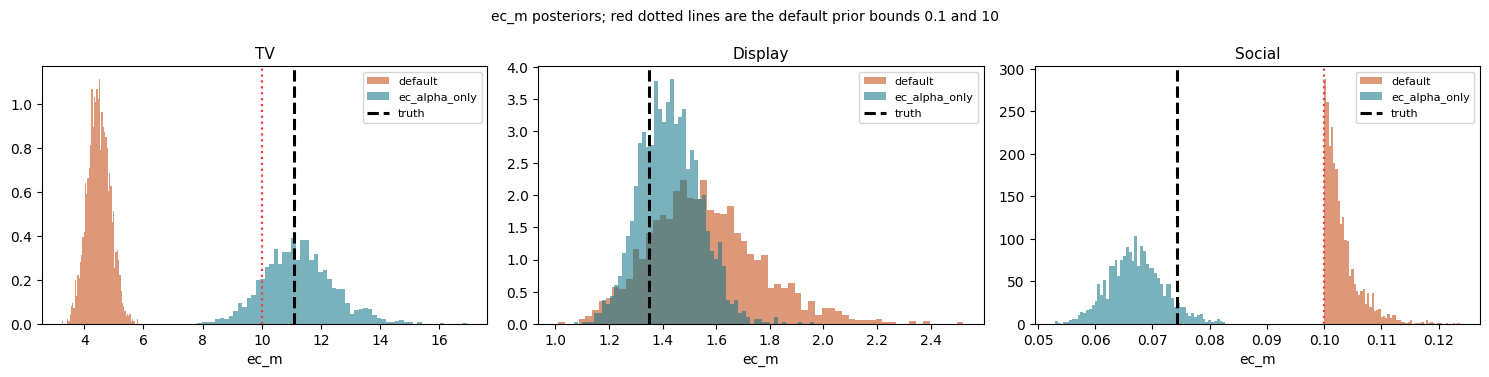

,variant,channel,true_ec_m,post_mean,post_p5,frac_within_10pct_of_floor,frac_within_10pct_of_ceiling
0,default,TV,11.0694,4.4901,3.8694,0.00,0.000
1,default,Display,1.3505,1.5585,1.2536,0.00,0.000
2,default,Social,0.0742,0.1031,0.1002,0.96,0.000
3,ec_alpha_only,TV,11.0694,11.2544,9.4022,0.00,0.982
4,ec_alpha_only,Display,1.3505,1.4261,1.2541,0.00,0.000
5,ec_alpha_only,Social,0.0742,0.0672,0.0596,1.00,0.000


In [6]:
rows = []
for variant in VARIANTS:
  post = fitted_mmms[variant].inference_data.posterior['ec_m'].values
  for i, ch in enumerate(channels):
    d = post[..., i].ravel()
    rows.append({
        'variant': variant, 'channel': ch,
        'true_ec_m': round(float(true_ec_m[i]), 4),
        'post_mean': round(float(d.mean()), 4),
        'post_p5': round(float(np.percentile(d, 5)), 4),
        'frac_within_10pct_of_floor': round(
            float((d < EC_PRIOR_LOW * 1.1).mean()), 3),
        'frac_within_10pct_of_ceiling': round(
            float((d > EC_PRIOR_HIGH * 0.9).mean()), 3),
    })
boundary = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for i, (ch, ax) in enumerate(zip(channels, axes)):
    for variant, color in [('default', '#c1440e'), ('ec_alpha_only', '#0b7285')]:
        d = fitted_mmms[variant].inference_data.posterior['ec_m'].values[..., i].ravel()
        ax.hist(d, bins=60, density=True, alpha=0.55, color=color, label=variant)
    ax.axvline(true_ec_m[i], color='k', lw=2.2, ls='--', label='truth')
    for bound in (EC_PRIOR_LOW, EC_PRIOR_HIGH):
        if ax.get_xlim()[0] <= bound <= ax.get_xlim()[1] * 1.5:
            ax.axvline(bound, color='#f03e3e', lw=1.6, ls=':')
    ax.set_title(ch, fontsize=11)
    ax.set_xlabel('ec_m')
    ax.legend(fontsize=8)
plt.suptitle('ec_m posteriors; red dotted lines are the default prior bounds '
             '0.1 and 10', fontsize=10)
plt.tight_layout()
plt.show()

boundary

## 3. Result: both tails fail, in opposite directions

**Scorecard: `default` 3/9, `ec_alpha_only` 8/9** -- against 7/9 vs. 8/9 in the
one-tailed `alpha_08` scenario. Adding the lower tail roughly doubles the
separation.

### The censoring is visible in the posterior, not just the point estimate

| variant | channel | true | post. mean | post. p5 | draws within 10% of floor |
|---|---|---|---|---|---|
| `default` | Social | 0.0742 | **0.1031** | **0.1002** | **0.96** |
| `ec_alpha_only` | Social | 0.0742 | 0.0672 | 0.0596 | 0.00 (no floor) |

96% of `default`'s Social draws sit against the 0.1 boundary and the 5th
percentile is 0.1002 -- the posterior is *censored*, not merely uncertain. The
likelihood wants 0.074 and the prior forbids it. This is the most direct
evidence in the series that the binding constraint is the prior's **support**,
not its location or scale.

Note the `frac_within_10pct_of_ceiling` column is only meaningful for
`default`. `ec_alpha_only`'s LogNormal `ec_m` prior is unbounded, so its 0.982
for TV simply reflects a posterior correctly sitting near the true 11.25 -- it
is not pile-up.

### Mirror-image errors from one prior

| | true `ec_m` | `default` `ec_m` | what the model believes | `roi_m` error |
|---|---|---|---|---|
| TV (under-reached) | 11.069 | 4.490 (too low) | "already saturated" | **+21.8%** |
| Social (over-saturated) | 0.074 | 0.103 (too high) | "still has headroom" | **-19.7%** |

Opposite `ec_m` errors produce opposite `roi_m` errors of similar magnitude,
from the same `TruncatedNormal(0.8, 0.8, [0.1, 10])` applied to both channels.
Display, sitting inside the support at `ec_m = 1.35`, recovers cleanly under
both variants -- so this is not a claim that the default prior is always wrong,
but that it fails specifically at both extremes of delivery.

**The talk framing this supports:**

> Meridian's default half-saturation prior spans [0.1, 10] and is applied
> identically to every channel. An under-reached TV channel needs 11.07. A
> saturated social channel needs 0.074. Neither is representable, and the two
> produce opposite budget errors: starve the channel with headroom, keep
> feeding the one that has none.

### Two caveats

**TV's `alpha_m` now misses under `default`** (0.832, interval 0.81-0.86,
against a true 0.800), where the same parameter was recovered -- by a margin of
0.002 -- in `roi-vs-mroi-metric-selection.ipynb`. That confirms the alpha
recovery at high retention is seed-fragile and should not be claimed without a
multi-seed sweep.

**Display's `alpha_m` misses under both variants.** Its `ec_m` and `roi_m`
recover, so the audience bump worked, but `build_alpha_prior`'s
`base_scale=0.1` is too diffuse around a true value of 0.078 for the informed
variant to help. A per-channel scale would fix it if `alpha_m` recovery ever
becomes part of the argument.

**Single seed** (`SIM_SEED = 0`), as with every notebook in this series. The
censoring mechanism is structural -- it follows from the prior's support, not
from any draw -- but the specific coverage counts are one realisation.